In [1]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import random
import os
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
from sklearn.model_selection import cross_validate

In [2]:
#Файлы
large_data_path = r'F:\datasets\whale-detection-challenge\whale_data\data' 
train_path = Path(large_data_path) / 'train'
test_path = Path(large_data_path) / 'test'

#Метки
train_csv_path = Path(large_data_path) / 'train.csv'
train_df = pd.read_csv(train_csv_path)

train_df = train_df.rename(columns={'clip_name_label': 'filename', 'train1.atif,0': 'label'})

train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
test_audio_files = list(test_path.rglob('*.aiff')) + list(test_path.rglob('*.aif'))

print(f"Размер датасета: {len(train_df)}")
print(f"Распределение меток:\n{train_df['label'].value_counts()}")


Размер датасета: 30000
Распределение меток:
label
0    22973
1     7027
Name: count, dtype: int64


In [3]:
def whale_denoise(y, sr, noise_reduction_db=10):
    """
    Специализированное шумоподавление для низкочастотных китовых звуков
    """
    # 1. Бандасс-фильтр для частот китов (50-1000 Hz)
    sos = librosa.filters.bandpass(low=50, high=1000, sr=sr)
    y_filtered = sosfilt(sos, y)
    
    # 2. Spectral gating (пороговое шумоподавление)
    D = librosa.stft(y_filtered)
    magnitude = np.abs(D)
    
    # Оценка шума (первые 0.1 секунды)
    noise_frames = magnitude[:, :int(0.1 * sr / 2048)]
    noise_profile = np.mean(noise_frames, axis=1)
    
    # Применяем spectral subtraction
    threshold = noise_profile * (10 ** (noise_reduction_db / 20))
    magnitude_denoised = np.maximum(magnitude - threshold.reshape(-1, 1), 0)
    
    # Восстанавливаем сигнал
    D_denoised = magnitude_denoised * np.exp(1j * np.angle(D))
    y_denoised = librosa.istft(D_denoised)
    
    return y_denoised

def extract_denoised_features(audio_file, sr=22050):
    """Извлечение признаков с шумоподавлением"""
    y, sr = librosa.load(audio_file, sr=sr)
    
    # Применяем шумоподавление
    y_clean = whale_denoise(y, sr)
    
    # Извлекаем признаки из очищенного сигнала
    features = {}
    
    # Только самые важные признаки
    chroma_stft = librosa.feature.chroma_stft(y=y_clean, sr=sr)
    features['chroma_stft_mean'] = np.mean(chroma_stft, axis=1)
    features['chroma_stft_std'] = np.std(chroma_stft, axis=1)
    
    # Спектральные центроид и rolloff более устойчивы к шуму
    features['spectral_centroid'] = np.mean(librosa.feature.spectral_centroid(y=y_clean, sr=sr))
    features['spectral_rolloff'] = np.mean(librosa.feature.spectral_rolloff(y=y_clean, sr=sr))
    
    # RMS энергии в низкочастотном диапазоне (где киты)
    low_freq_energy = np.mean(librosa.feature.rms(y=y_clean)[0])
    features['low_freq_rms'] = low_freq_energy
    
    # MFCC (только первые 5 коэффициентов)
    mfccs = librosa.feature.mfcc(y=y_clean, sr=sr, n_mfcc=5)
    for i in range(5):
        features[f'mfcc_{i}'] = np.mean(mfccs[i])
    
    return features

In [4]:
def create_clean_spectrograms(cleaned_audio_data):
    spectrograms_data = []
    
    for audio_item in cleaned_audio_data:
        y_clean = audio_item['audio_clean']
        sr = audio_item['sr']
        
        # Строим спектрограммы из ОЧИЩЕННОГО аудио
        mel_spec = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128, fmax=2000)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # STFT спектрограмма из очищенного аудио
        D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
        
        spectrograms_data.append({
            'filename': audio_item['filename'],
            'mel_spectrogram': mel_spec_db,
            'stft_spectrogram': D_clean,
            'label': audio_item['label'],
            'audio_clean': audio_item['audio_clean'],
            'sr': sr
        })
    
    return spectrograms_data

In [6]:
from scipy.signal import butter, filtfilt, sosfilt

def whale_denoise(y, sr, noise_reduction_db=10, low_freq=50, high_freq=1000):
    """
    Специализированное шумоподавление для низкочастотных китовых звуков
    """
    try:
        # 1. Бандасс-фильтр для частот китов (50-1000 Hz) - исправленная версия
        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyquist = 0.5 * fs
            low = lowcut / nyquist
            high = highcut / nyquist
            sos = butter(order, [low, high], btype='band', output='sos')
            return sos
        
        sos = butter_bandpass(low_freq, high_freq, sr)
        y_filtered = sosfilt(sos, y)
        
        # 2. Spectral gating (пороговое шумоподавление)
        D = librosa.stft(y_filtered)
        magnitude = np.abs(D)
        
        # Оценка шума (первые 0.1 секунды)
        frame_length = 2048
        hop_length = 512
        noise_frames = magnitude[:, :int(0.1 * sr / hop_length)]
        noise_profile = np.mean(noise_frames, axis=1)
        
        # Применяем spectral subtraction
        threshold = noise_profile * (10 ** (noise_reduction_db / 20))
        magnitude_denoised = np.maximum(magnitude - threshold.reshape(-1, 1), 0)
        
        # Восстанавливаем сигнал
        D_denoised = magnitude_denoised * np.exp(1j * np.angle(D))
        y_denoised = librosa.istft(D_denoised)
        
        return y_denoised
    
    except Exception as e:
        print(f"Ошибка в шумоподавлении: {e}")
        # Возвращаем оригинальный сигнал в случае ошибки
        return y

# Альтернативная упрощенная версия шумоподавления
def simple_whale_denoise(y, sr):
    """
    Упрощенное шумоподавление для китовых звуков
    """
    try:
        # 1. Фильтр низких частот (киты в диапазоне до 1000 Hz)
        from scipy.signal import butter, filtfilt
        def butter_lowpass(cutoff, fs, order=4):
            nyq = 0.5 * fs
            normal_cutoff = cutoff / nyq
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return b, a
        
        b, a = butter_lowpass(1000, sr)
        y_filtered = filtfilt(b, a, y)
        
        # 2. Простое спектральное вычитание
        D = librosa.stft(y_filtered, n_fft=2048, hop_length=512)
        magnitude = np.abs(D)
        
        # Оценка шума по первым кадрам
        noise_frames = magnitude[:, :10]  # первые 10 кадров
        noise_profile = np.mean(noise_frames, axis=1)
        
        # Вычитание шума
        magnitude_clean = np.maximum(magnitude - 0.5 * noise_profile.reshape(-1, 1), 0.01)
        
        # Восстановление сигнала
        D_clean = magnitude_clean * np.exp(1j * np.angle(D))
        y_clean = librosa.istft(D_clean)
        
        return y_clean
    
    except Exception as e:
        print(f"Ошибка в упрощенном шумоподавлении: {e}")
        return y

In [ ]:
def compare_spectrograms_before_after(audio_files, labels_df, num_samples=2, sr=22050):
    """
    Сравнение спектрограмм до и после шумоподавления для разных классов
    """
    # Разделяем файлы по классам
    class_0_files = []
    class_1_files = []
    
    for audio_file in audio_files[:200]:
        try:
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            if not matching_row.empty:
                label = matching_row['label'].iloc[0]
                if label == 0 and len(class_0_files) < num_samples:
                    class_0_files.append(audio_file)
                elif label == 1 and len(class_1_files) < num_samples:
                    class_1_files.append(audio_file)
                
                if len(class_0_files) >= num_samples and len(class_1_files) >= num_samples:
                    break
        except:
            continue
    
    print(f"Найдено файлов: Class 0 - {len(class_0_files)}, Class 1 - {len(class_1_files)}")
    
    # Создаем график с правильными размерами
    n_rows = 4  # 2 типа спектрограмм × 2 класса
    n_cols = num_samples * 2  # до/после для каждого файла
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
    
    # Функция для построения спектрограмм одного файла
    def plot_spectrograms_for_file(audio_file, label, file_idx, sr=22050):
        try:
            # Загружаем оригинальное аудио
            y_orig, sr = librosa.load(audio_file, sr=sr, duration=2.0)  # ограничиваем длительность
            filename = audio_file.stem  # только имя файла без пути
            
            # Применяем шумоподавление
            y_clean = simple_whale_denoise(y_orig, sr)
            
            # Типы спектрограмм для сравнения
            spectrogram_types = [
                ('Mel-spectrogram', 'viridis', 'mel'),
                ('STFT Spectrogram', 'plasma', 'hz')
            ]
            
            for spec_idx, (spec_type, cmap, y_axis) in enumerate(spectrogram_types):
                # ОРИГИНАЛ (до шумоподавления)
                col_orig = file_idx * 2
                ax_orig = axes[spec_idx * 2, col_orig]
                
                if spec_type == 'Mel-spectrogram':
                    spec_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr, n_mels=128, fmax=2000)
                    spec_orig_db = librosa.power_to_db(spec_orig, ref=np.max)
                    librosa.display.specshow(spec_orig_db, sr=sr, x_axis='time', y_axis=y_axis, 
                                           ax=ax_orig, cmap=cmap)
                else:
                    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
                    librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis=y_axis,
                                           ax=ax_orig, cmap=cmap)
                
                ax_orig.set_title(f'{spec_type}\nДО ({filename})', fontsize=10)
                ax_orig.text(0.02, 0.98, f'Класс: {"КИТ" if label == 1 else "НЕТ КИТА"}', 
                           transform=ax_orig.transAxes, fontsize=8, 
                           verticalalignment='top', 
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
                # ПОСЛЕ шумоподавления
                col_clean = file_idx * 2 + 1
                ax_clean = axes[spec_idx * 2, col_clean]
                
                if spec_type == 'Mel-spectrogram':
                    spec_clean = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128, fmax=2000)
                    spec_clean_db = librosa.power_to_db(spec_clean, ref=np.max)
                    img = librosa.display.specshow(spec_clean_db, sr=sr, x_axis='time', y_axis=y_axis, 
                                                 ax=ax_clean, cmap=cmap)
                else:
                    D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
                    img = librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis=y_axis,
                                                 ax=ax_clean, cmap=cmap)
                
                ax_clean.set_title(f'{spec_type}\nПОСЛЕ ({filename})', fontsize=10)
                ax_clean.text(0.02, 0.98, f'Класс: {"КИТ" if label == 1 else "НЕТ КИТА"}', 
                            transform=ax_clean.transAxes, fontsize=8,
                            verticalalignment='top', 
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
                # Добавляем colorbar для последнего графика
                if file_idx == num_samples - 1 and spec_idx == len(spectrogram_types) - 1:
                    plt.colorbar(img, ax=ax_clean, fraction=0.046, pad=0.04)
                    
        except Exception as e:
            print(f"Ошибка обработки {audio_file}: {e}")
    
    # Построение для класса 0 (нет кита)
    for i, audio_file in enumerate(class_0_files):
        plot_spectrograms_for_file(audio_file, label=0, file_idx=i, sr=sr)
    
    # Построение для класса 1 (кит)
    for i, audio_file in enumerate(class_1_files):
        plot_spectrograms_for_file(audio_file, label=1, file_idx=i, sr=sr)
    
    # Скрываем пустые subplots
    total_plots = len(class_0_files) + len(class_1_files)
    for i in range(total_plots * 2, n_cols):
        for j in range(n_rows):
            fig.delaxes(axes[j, i])
    
    plt.tight_layout()
    plt.show()
    
    return fig

def compare_spectrogram_types_single_file(audio_file, label, sr=22050):
    """
    Сравнение разных типов спектрограмм для одного файла
    """
    try:
        y_orig, sr = librosa.load(audio_file, sr=sr, duration=2.0)
        y_clean = simple_whale_denoise(y_orig, sr)
        filename = audio_file.stem
        
        spectrogram_types = [
            ('Mel-spectrogram', 'viridis', 'mel'),
            ('STFT Spectrogram', 'plasma', 'hz'),
            ('Chromagram', 'coolwarm', 'chroma'),
            ('Spectral Contrast', 'Reds', None)
        ]
        
        fig, axes = plt.subplots(2, 4, figsize=(20, 8))
        
        for i, (spec_type, cmap, y_axis) in enumerate(spectrogram_types):
            # ДО шумоподавления
            ax_orig = axes[0, i]
            
            if spec_type == 'Mel-spectrogram':
                spec = librosa.feature.melspectrogram(y=y_orig, sr=sr, n_mels=128, fmax=2000)
                spec_db = librosa.power_to_db(spec, ref=np.max)
                librosa.display.specshow(spec_db, sr=sr, x_axis='time', y_axis=y_axis, 
                                       ax=ax_orig, cmap=cmap)
            elif spec_type == 'STFT Spectrogram':
                D = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
                librosa.display.specshow(D, sr=sr, x_axis='time', y_axis=y_axis,
                                       ax=ax_orig, cmap=cmap)
            elif spec_type == 'Chromagram':
                chroma = librosa.feature.chroma_stft(y=y_orig, sr=sr)
                librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis=y_axis,
                                       ax=ax_orig, cmap=cmap)
            else:  # Spectral Contrast
                contrast = librosa.feature.spectral_contrast(y=y_orig, sr=sr)
                librosa.display.specshow(contrast, sr=sr, x_axis='time',
                                       ax=ax_orig, cmap=cmap)
            
            ax_orig.set_title(f'{spec_type}\nДО шумоподавления', fontsize=12)
            ax_orig.text(0.02, 0.98, f'Класс: {"КИТ" if label == 1 else "НЕТ КИТА"}', 
                       transform=ax_orig.transAxes, fontsize=9,
                       verticalalignment='top', 
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            # ПОСЛЕ шумоподавления
            ax_clean = axes[1, i]
            
            if spec_type == 'Mel-spectrogram':
                spec = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128, fmax=2000)
                spec_db = librosa.power_to_db(spec, ref=np.max)
                img = librosa.display.specshow(spec_db, sr=sr, x_axis='time', y_axis=y_axis, 
                                             ax=ax_clean, cmap=cmap)
            elif spec_type == 'STFT Spectrogram':
                D = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
                img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis=y_axis,
                                             ax=ax_clean, cmap=cmap)
            elif spec_type == 'Chromagram':
                chroma = librosa.feature.chroma_stft(y=y_clean, sr=sr)
                img = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis=y_axis,
                                             ax=ax_clean, cmap=cmap)
            else:  # Spectral Contrast
                contrast = librosa.feature.spectral_contrast(y=y_clean, sr=sr)
                img = librosa.display.specshow(contrast, sr=sr, x_axis='time',
                                             ax=ax_clean, cmap=cmap)
            
            ax_clean.set_title(f'{spec_type}\nПОСЛЕ шумоподавления', fontsize=12)
            ax_clean.text(0.02, 0.98, f'Класс: {"КИТ" if label == 1 else "НЕТ КИТА"}', 
                        transform=ax_clean.transAxes, fontsize=9,
                        verticalalignment='top', 
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            # Добавляем colorbar для последнего графика
            if i == len(spectrogram_types) - 1:
                plt.colorbar(img, ax=ax_clean, fraction=0.046, pad=0.04)
        
        # Добавляем общую информацию о файле
        plt.suptitle(f'Сравнение спектрограмм: {filename}\nКласс: {"КИТ" if label == 1 else "НЕТ КИТА"}', 
                     fontsize=16, y=1.02)
        
        plt.tight_layout()
        plt.show()
        
        return fig
        
    except Exception as e:
        print(f"Ошибка при обработке файла {audio_file}: {e}")
        return None

# Упрощенная версия для быстрого тестирования
def quick_spectrogram_comparison(audio_files, labels_df, n_files=2, sr=22050):
    """
    Быстрое сравнение спектрограмм для нескольких файлов
    """
    fig, axes = plt.subplots(n_files, 4, figsize=(16, 4 * n_files))
    
    if n_files == 1:
        axes = axes.reshape(1, -1)
    
    files_processed = 0
    
    for i, audio_file in enumerate(audio_files[:20]):
        if files_processed >= n_files:
            break
            
        try:
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            if matching_row.empty:
                continue
                
            label = matching_row['label'].iloc[0]
            y_orig, sr = librosa.load(audio_file, sr=sr, duration=2.0)
            y_clean = simple_whale_denoise(y_orig, sr)
            
            # Mel-spectrogram ДО
            spec_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr, n_mels=128, fmax=2000)
            spec_orig_db = librosa.power_to_db(spec_orig, ref=np.max)
            librosa.display.specshow(spec_orig_db, sr=sr, x_axis='time', y_axis='mel', 
                                   ax=axes[files_processed, 0], cmap='viridis')
            axes[files_processed, 0].set_title(f'Mel ДО\n{"КИТ" if label == 1 else "НЕТ КИТА"}')
            
            # Mel-spectrogram ПОСЛЕ
            spec_clean = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128, fmax=2000)
            spec_clean_db = librosa.power_to_db(spec_clean, ref=np.max)
            librosa.display.specshow(spec_clean_db, sr=sr, x_axis='time', y_axis='mel', 
                                   ax=axes[files_processed, 1], cmap='viridis')
            axes[files_processed, 1].set_title(f'Mel ПОСЛЕ\n{"КИТ" if label == 1 else "НЕТ КИТА"}')
            
            # STFT ДО
            D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
            librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='hz',
                                   ax=axes[files_processed, 2], cmap='plasma')
            axes[files_processed, 2].set_title(f'STFT ДО\n{"КИТ" if label == 1 else "НЕТ КИТА"}')
            
            # STFT ПОСЛЕ
            D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
            img = librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis='hz',
                                         ax=axes[files_processed, 3], cmap='plasma')
            axes[files_processed, 3].set_title(f'STFT ПОСЛЕ\n{"КИТ" if label == 1 else "НЕТ КИТА"}')
            
            files_processed += 1
            
        except Exception as e:
            print(f"Ошибка обработки {audio_file}: {e}")
            continue
    
    plt.tight_layout()
    plt.show()
    
    return fig

1. Быстрое сравнение спектрограмм:
Ошибка обработки F:\datasets\whale-detection-challenge\whale_data\data\train\train1.aiff: amplitude_to_db() got an unexpected keyword argument 'fmax'
Ошибка обработки F:\datasets\whale-detection-challenge\whale_data\data\train\train10.aiff: amplitude_to_db() got an unexpected keyword argument 'fmax'
Ошибка обработки F:\datasets\whale-detection-challenge\whale_data\data\train\train100.aiff: amplitude_to_db() got an unexpected keyword argument 'fmax'
Ошибка обработки F:\datasets\whale-detection-challenge\whale_data\data\train\train1000.aiff: amplitude_to_db() got an unexpected keyword argument 'fmax'
Ошибка обработки F:\datasets\whale-detection-challenge\whale_data\data\train\train10000.aiff: amplitude_to_db() got an unexpected keyword argument 'fmax'
Ошибка обработки F:\datasets\whale-detection-challenge\whale_data\data\train\train10001.aiff: amplitude_to_db() got an unexpected keyword argument 'fmax'
Ошибка обработки F:\datasets\whale-detection-challe

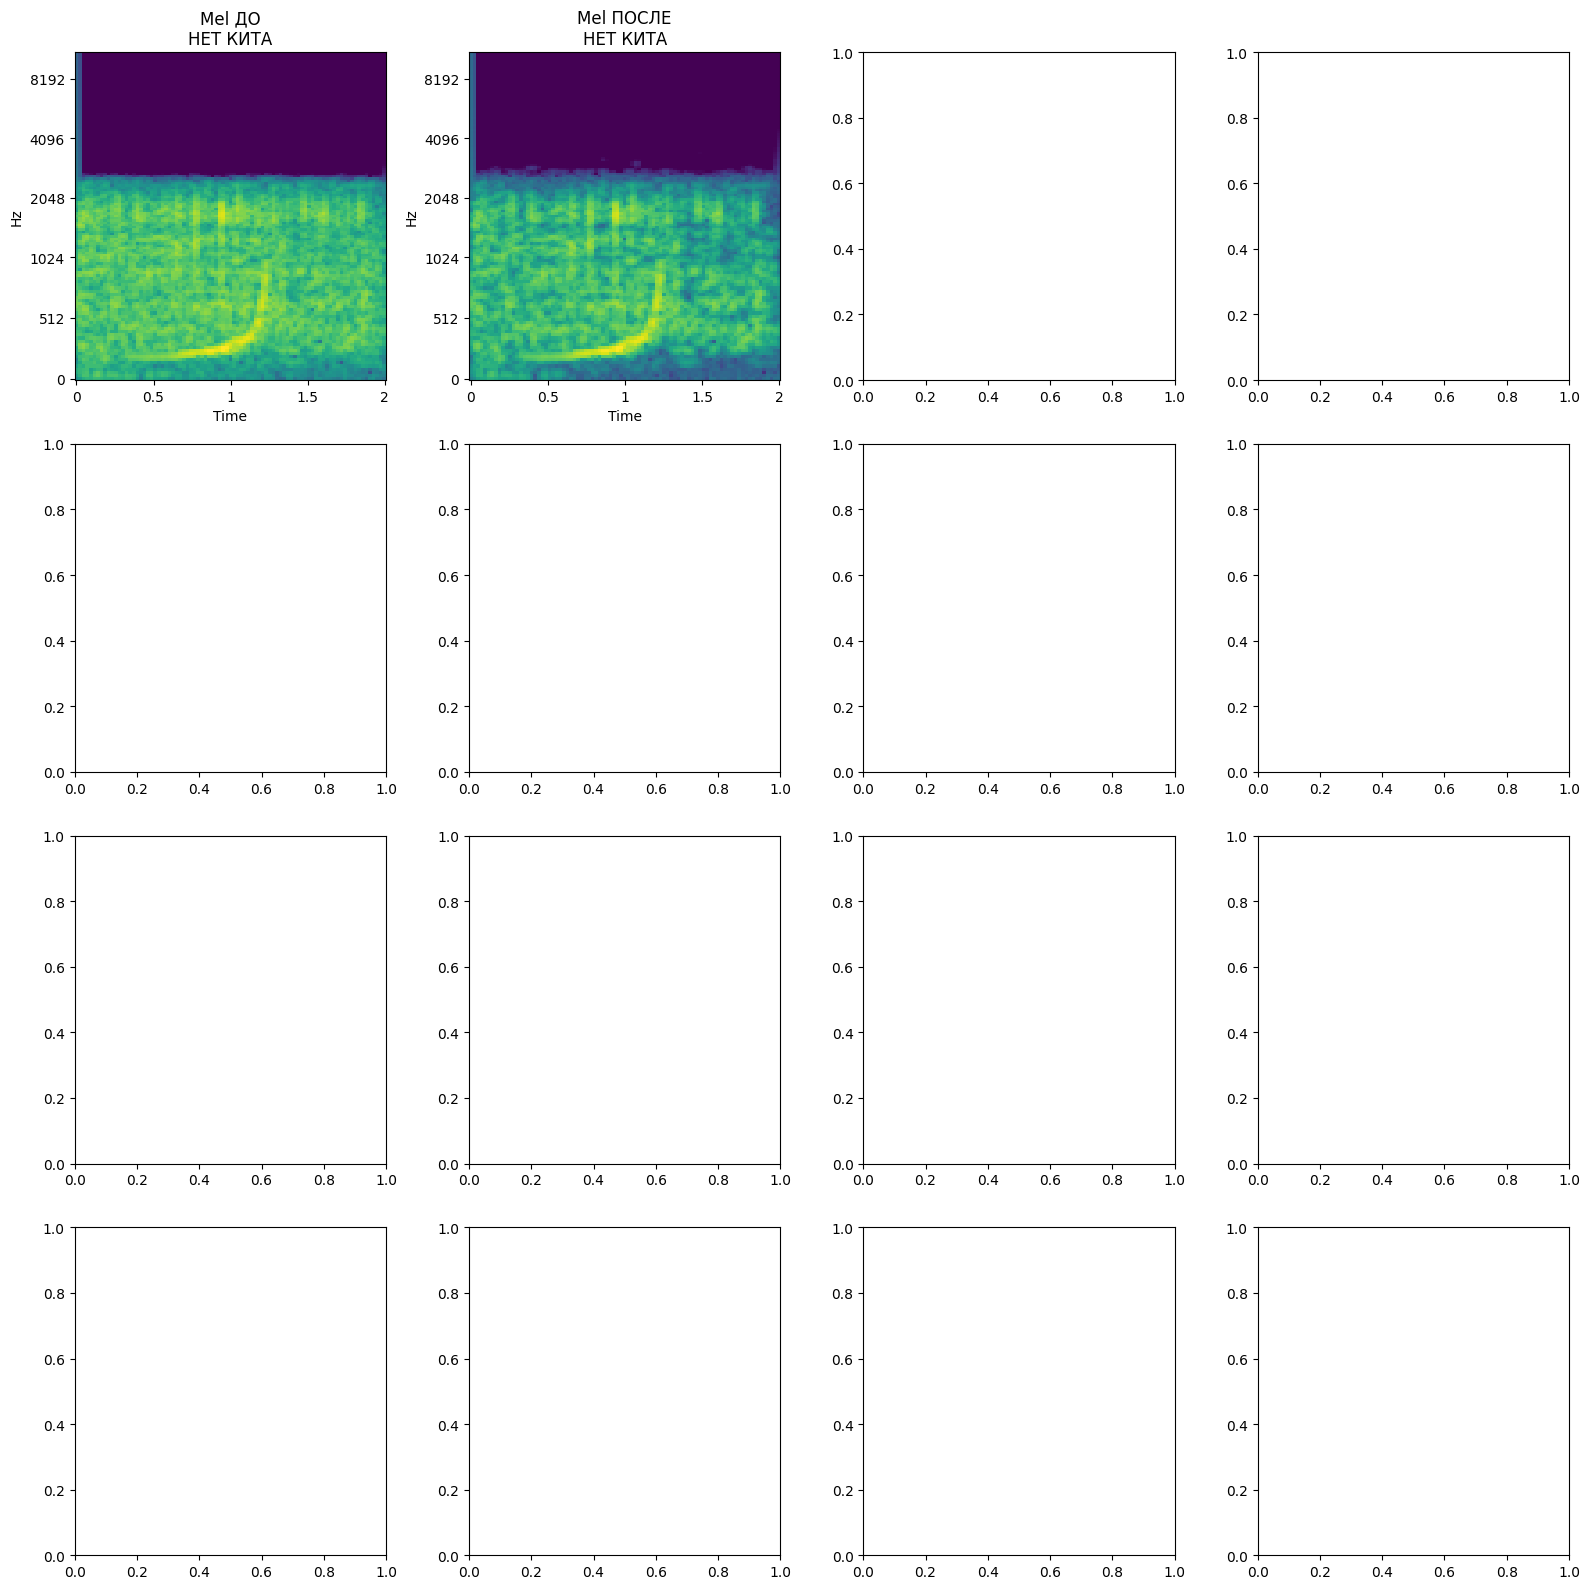


2. Детальное сравнение для отдельных файлов:
Файл БЕЗ кита: train1.aiff


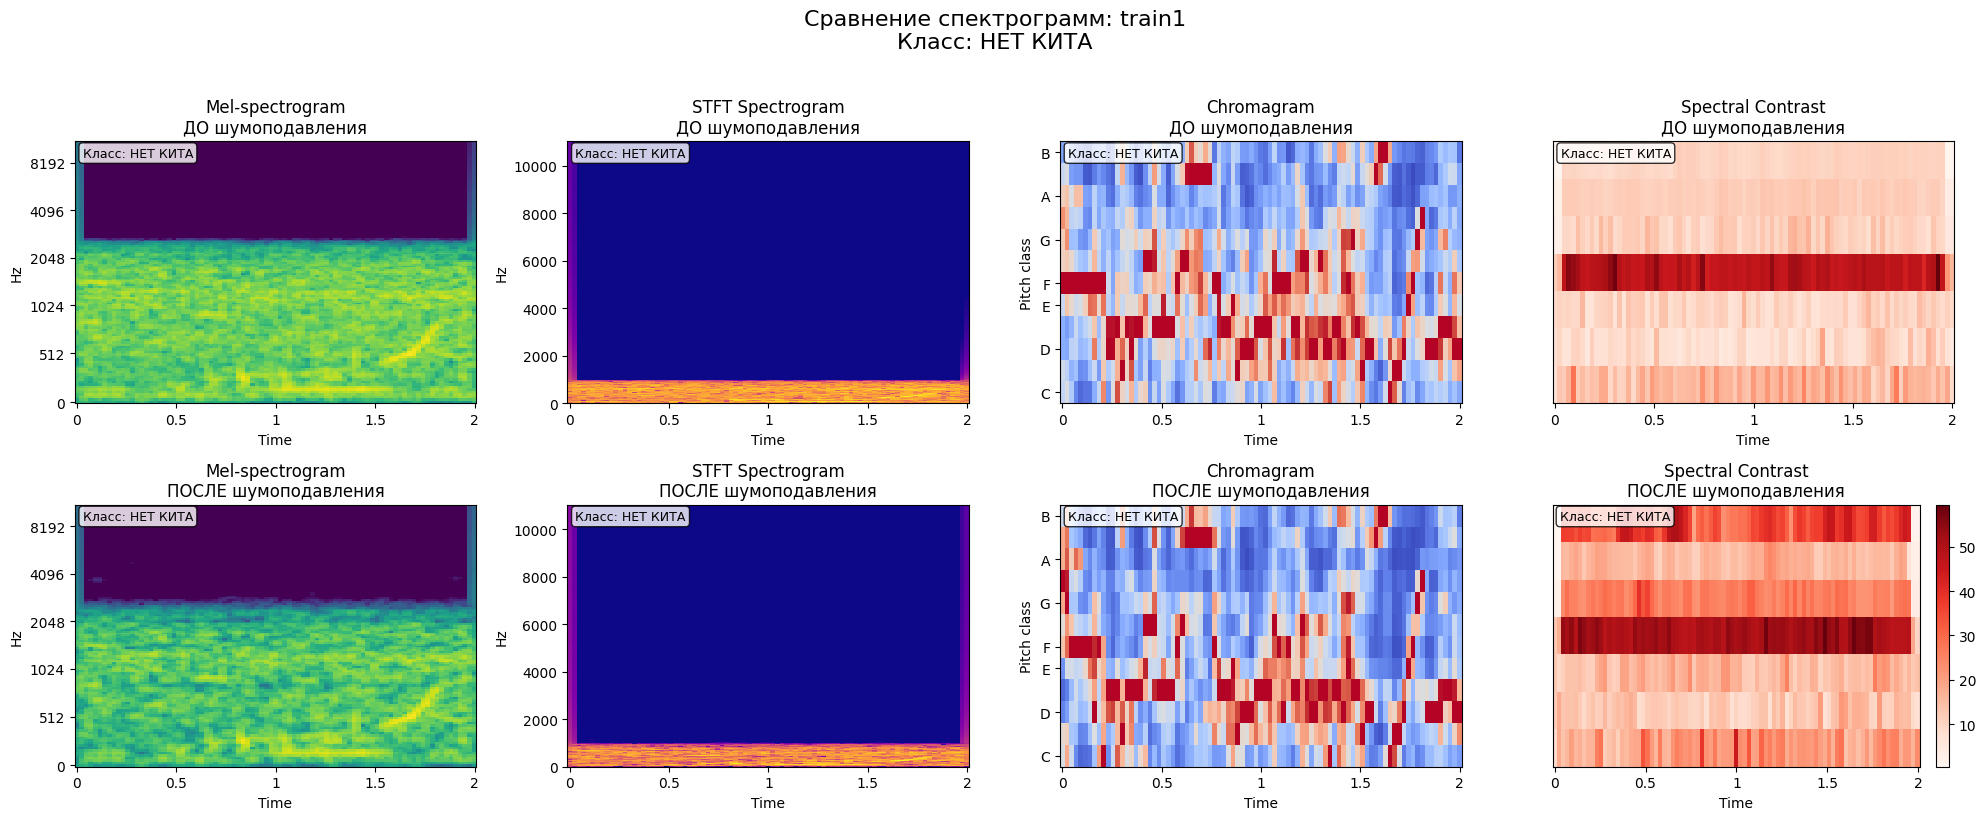

Файл С китом: train1000.aiff


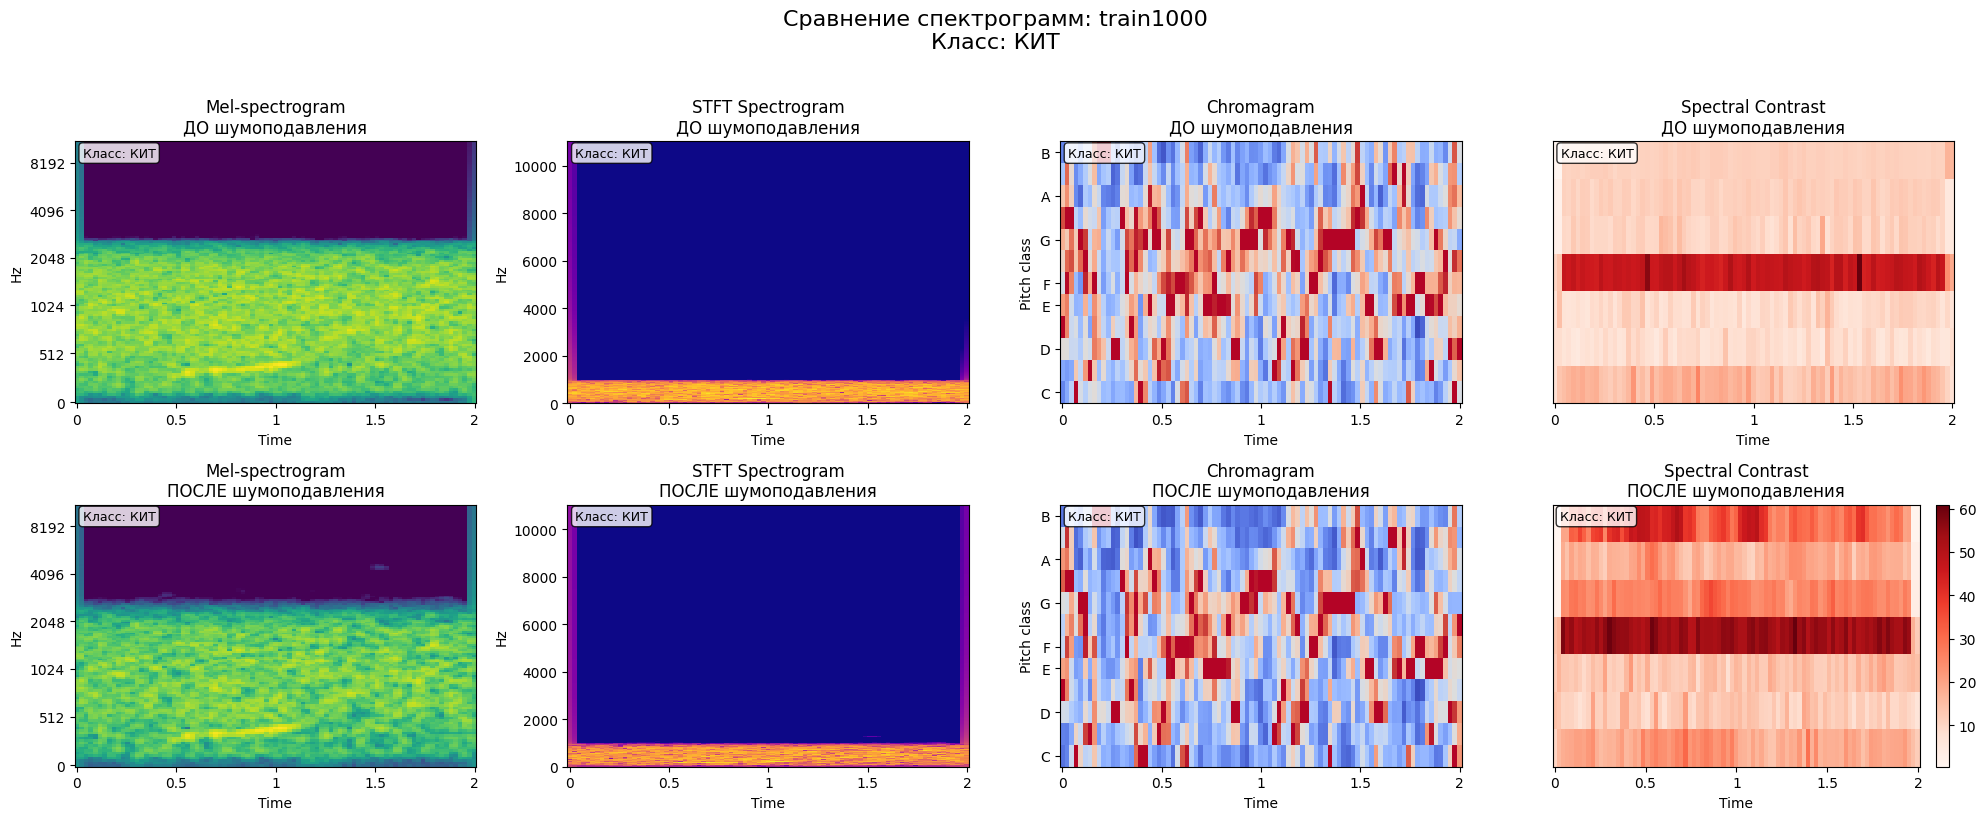

In [12]:
print("1. Быстрое сравнение спектрограмм:")
fig1 = quick_spectrogram_comparison(train_audio_files, train_df, n_files=4)

print("\n2. Детальное сравнение для отдельных файлов:")
# Находим по одному файлу каждого класса
class_0_sample = None
class_1_sample = None

for audio_file in train_audio_files[:100]:
    filename = audio_file.name
    matching_row = train_df[train_df['clip_name'] == filename]
    if not matching_row.empty:
        label = matching_row['label'].iloc[0]
        if label == 0 and class_0_sample is None:
            class_0_sample = audio_file
        elif label == 1 and class_1_sample is None:
            class_1_sample = audio_file
        
        if class_0_sample and class_1_sample:
            break

if class_0_sample:
    print(f"Файл БЕЗ кита: {class_0_sample.name}")
    fig2 = compare_spectrogram_types_single_file(class_0_sample, label=0)

if class_1_sample:
    print(f"Файл С китом: {class_1_sample.name}")
    fig3 = compare_spectrogram_types_single_file(class_1_sample, label=1)

1. Случайные спектрограммы:


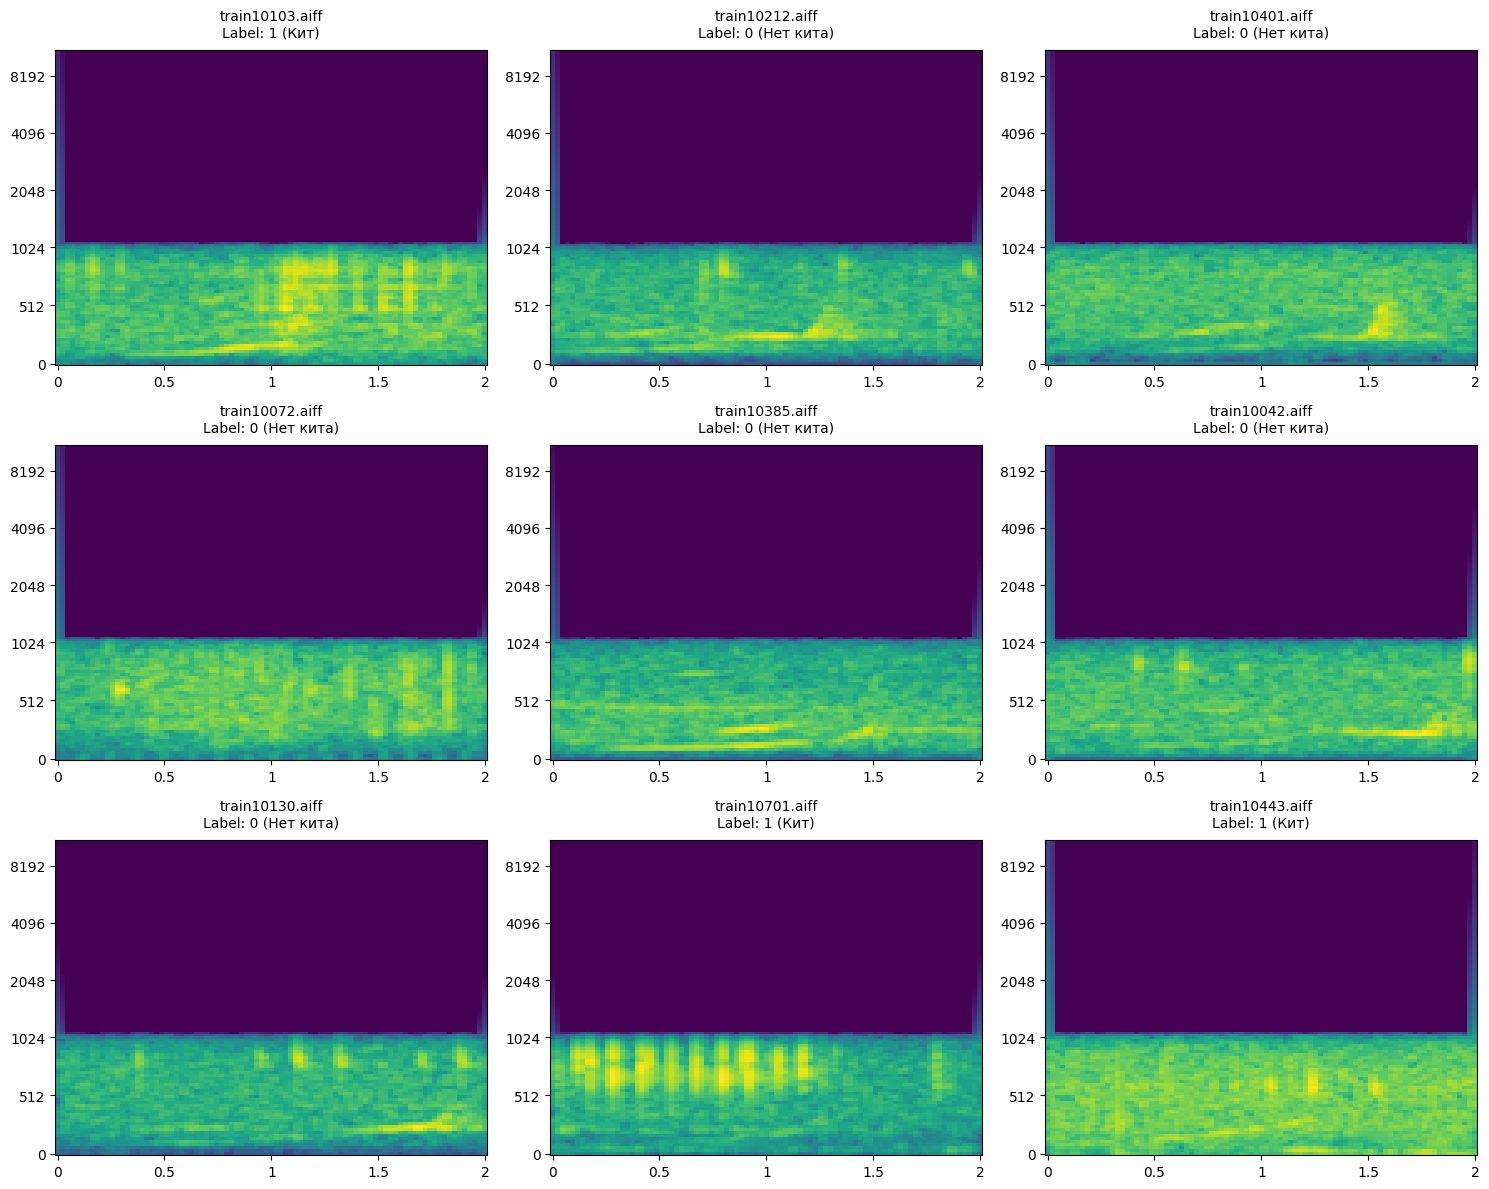

2. Сравнение спектрограмм разных классов:


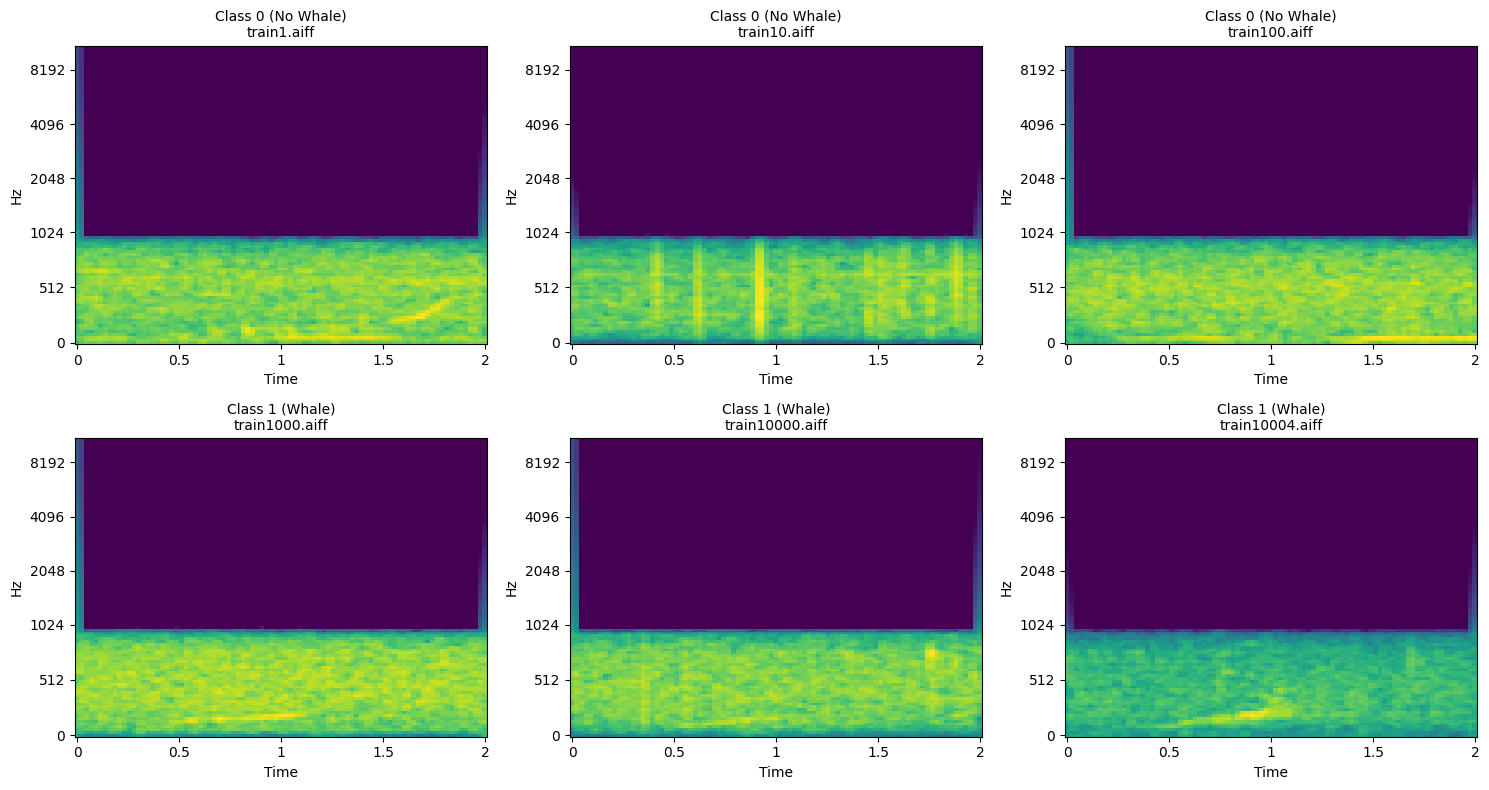

3. Анализ длительности аудиофайлов:


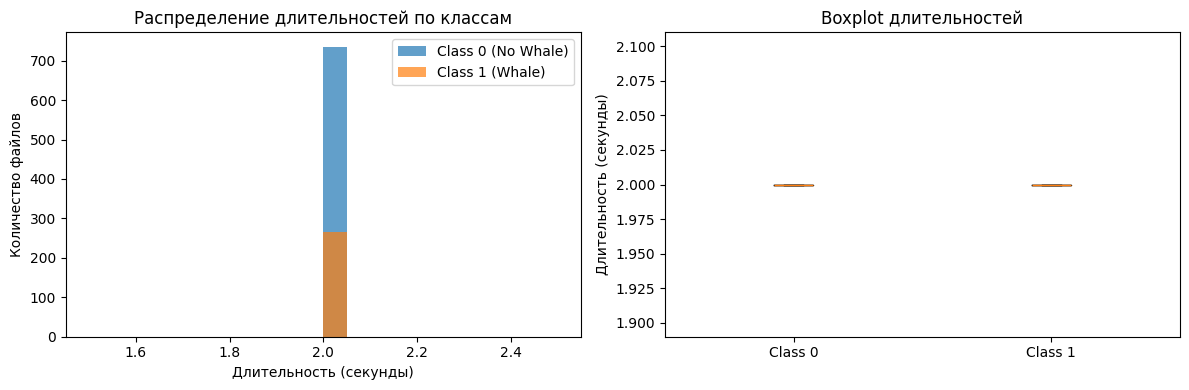

Class 0: 735 файлов, средняя длительность: 2.00 сек
Class 1: 265 файлов, средняя длительность: 2.00 сек
4. Разные типы спектрограмм для одного файла:


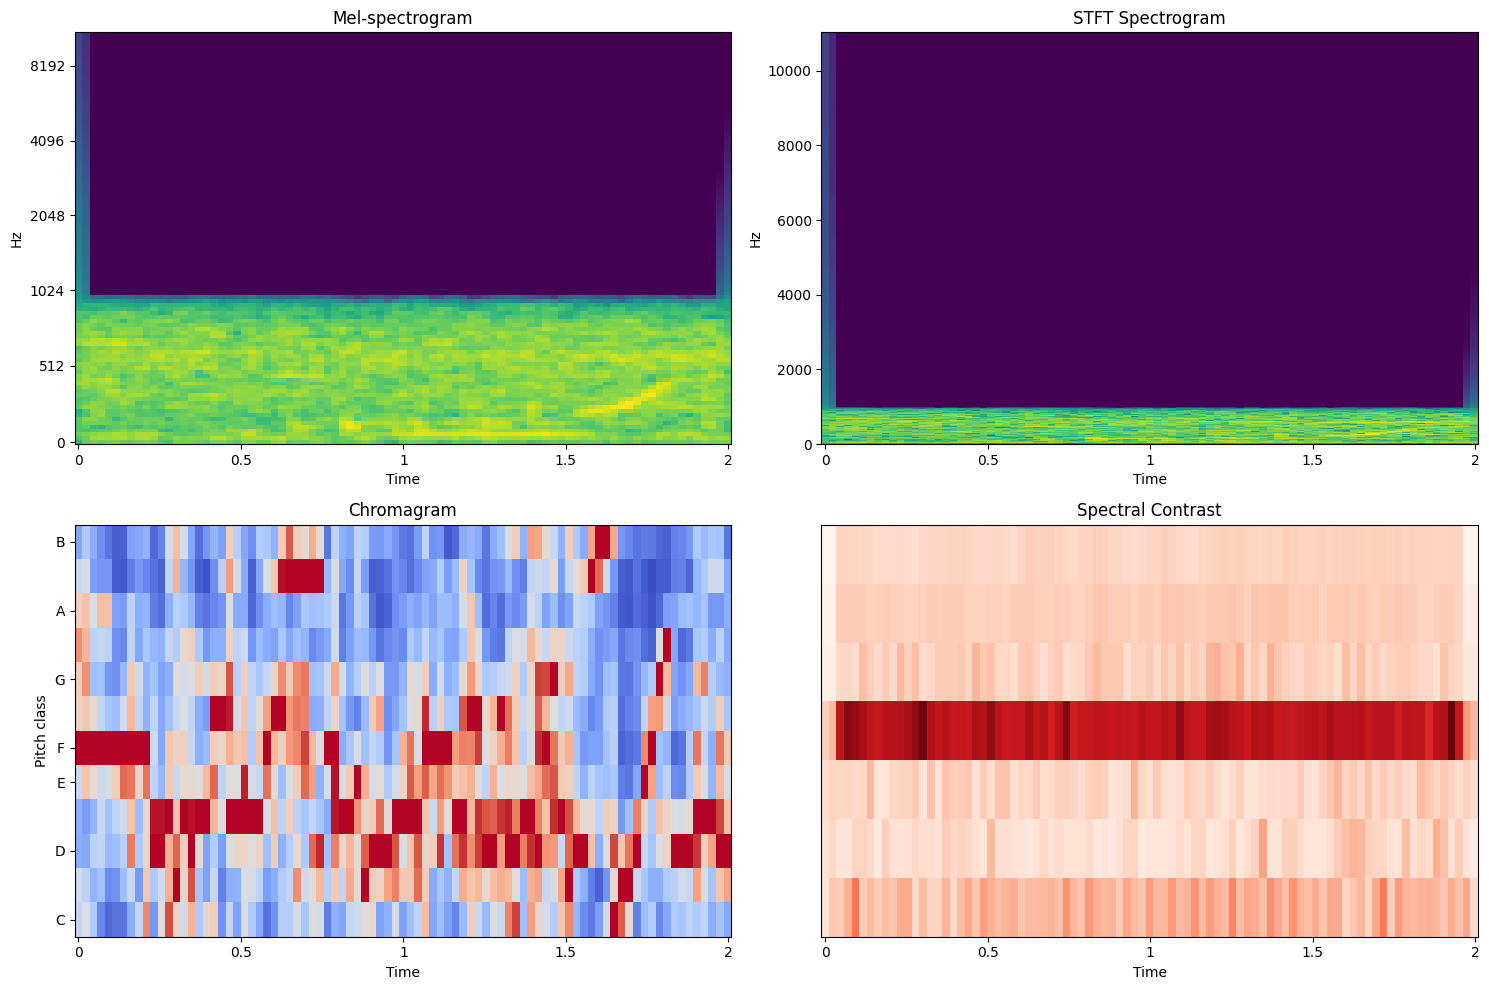

In [3]:
#спектрограммы
def plot_random_spectrograms(audio_files, labels_df, num_samples=9, sr=22050):
    random_files = random.sample(audio_files, min(num_samples, len(audio_files)))
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, audio_file in enumerate(random_files):
        try:
            y, sr = librosa.load(audio_file, sr=sr, duration=5)
            
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            label = matching_row['label'].iloc[0] if not matching_row.empty else "Unknown"

            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                                         ax=axes[i], cmap='viridis')
            
            axes[i].set_title(f'{filename}\nLabel: {label} ({"Кит" if label == 1 else "Нет кита"})', 
                            fontsize=10, pad=10)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')
            
        except Exception as e:
            axes[i].set_title(f'Error: {audio_file.name}')
            print(f"Ошибка обработки {audio_file}: {e}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    return fig

def compare_classes_spectrograms(audio_files, labels_df, num_per_class=3, sr=22050):
    class_0_files = []
    class_1_files = []
    
    for audio_file in audio_files[:1000]:  
        try:
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            if not matching_row.empty:
                label = matching_row['label'].iloc[0]
                if label == 0 and len(class_0_files) < num_per_class:
                    class_0_files.append(audio_file)
                elif label == 1 and len(class_1_files) < num_per_class:
                    class_1_files.append(audio_file)
                
                if len(class_0_files) >= num_per_class and len(class_1_files) >= num_per_class:
                    break
        except:
            continue
    
    fig, axes = plt.subplots(2, num_per_class, figsize=(15, 8))
    #0 (no whale)
    for i, audio_file in enumerate(class_0_files):
        y, sr = librosa.load(audio_file, sr=sr, duration=5)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                               ax=axes[0, i], cmap='viridis')
        axes[0, i].set_title(f'Class 0 (No Whale)\n{audio_file.name}', fontsize=10)
    
    #1 (whale)
    for i, audio_file in enumerate(class_1_files):
        y, sr = librosa.load(audio_file, sr=sr, duration=5)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                               ax=axes[1, i], cmap='viridis')
        axes[1, i].set_title(f'Class 1 (Whale)\n{audio_file.name}', fontsize=10)
    
    plt.tight_layout()
    plt.show()

#длительность аудио
def audio_duration(audio_files, labels_df, max_files=1000):

    durations_0 = []
    durations_1 = []
    
    for i, audio_file in enumerate(audio_files[:max_files]):
        try:
            y, sr = librosa.load(audio_file, sr=22050)
            duration = len(y) / sr
            
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            if not matching_row.empty:
                label = matching_row['label'].iloc[0]
                if label == 0:
                    durations_0.append(duration)
                else:
                    durations_1.append(duration)
                    
        except Exception as e:
            continue
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(durations_0, alpha=0.7, label='Class 0 (No Whale)', bins=20)
    plt.hist(durations_1, alpha=0.7, label='Class 1 (Whale)', bins=20)
    plt.xlabel('Длительность (секунды)')
    plt.ylabel('Количество файлов')
    plt.legend()
    plt.title('Распределение длительностей по классам')
    
    plt.subplot(1, 2, 2)
    box_data = [durations_0, durations_1]
    plt.boxplot(box_data, labels=['Class 0', 'Class 1'])
    plt.ylabel('Длительность (секунды)')
    plt.title('Boxplot длительностей')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Class 0: {len(durations_0)} файлов, средняя длительность: {np.mean(durations_0):.2f} сек")
    print(f"Class 1: {len(durations_1)} файлов, средняя длительность: {np.mean(durations_1):.2f} сек")

#разные спектрограммы для 1 файла
def plot_different_spectrogram_types(audio_file, sr=22050):
    y, sr = librosa.load(audio_file, sr=sr, duration=5)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                           ax=axes[0, 0], cmap='viridis')
    axes[0, 0].set_title('Mel-spectrogram')
    
    # 2. STFT Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', 
                           ax=axes[0, 1], cmap='viridis')
    axes[0, 1].set_title('STFT Spectrogram')
    
    # 3. Chromagram
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', 
                           ax=axes[1, 0], cmap='coolwarm')
    axes[1, 0].set_title('Chromagram')
    
    # 4. Spectral Contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    librosa.display.specshow(contrast, sr=sr, x_axis='time', 
                           ax=axes[1, 1], cmap='Reds')
    axes[1, 1].set_title('Spectral Contrast')
    
    plt.tight_layout()
    plt.show()


print("1. Случайные спектрограммы:")
fig1 = plot_random_spectrograms(train_audio_files[:1000], train_df, num_samples=9)

print("2. Сравнение спектрограмм разных классов:")
fig2 = compare_classes_spectrograms(train_audio_files[:2000], train_df, num_per_class=3)

print("3. Анализ длительности аудиофайлов:")
audio_duration(train_audio_files[:2000], train_df)

if len(train_audio_files) > 0:
    print("4. Разные типы спектрограмм для одного файла:")
    sample_file = train_audio_files[0]
    plot_different_spectrogram_types(sample_file)

In [4]:
def extract_features(audio_files, labels_df=None, max_files=None): 
    features_data = []
    
    files_to_process = audio_files[:max_files] if max_files else audio_files
    
    for i, audio_file in enumerate(files_to_process):
        try:
            if i % 1000 == 0:
                print(f"{i}/{len(files_to_process)}")

            y, sr = librosa.load(audio_file, sr=22050, duration=10)
            
            # ЗАМЕНА MFCC НА РАСШИРЕННЫЕ ХРОМА-ПРИЗНАКИ
            chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)
            chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)                    # Хрома от постоянного Q-преобразования
            chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr)                  # CENS - энергетически нормализованная хрома
            
            # Существующие признаки
            spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)   
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y)          
            
            # ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ для обогащения хрома-анализа
            spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)      # Спектральный центроид
            spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)    # Спектральная ширина
            spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)        # Спектральный roll-off
            
            rms = librosa.feature.rms(y=y)                                         # RMS энергии
            tempo, _ = librosa.beat.beat_track(y=y, sr=sr)                         # Темп (для ритмических паттернов)

            label = None
            if labels_df is not None and 'label' in labels_df.columns:
                filename = audio_file.name
                matching_row = labels_df[labels_df['clip_name'] == filename]
                
                if not matching_row.empty:
                    label = matching_row['label'].iloc[0]
            
            features_data.append({
                'filename': audio_file.name,
                'filepath': str(audio_file),
                'label': label,
                'duration': len(y) / sr,
                'sample_rate': sr,
                
                # ХРОМА-ПРИЗНАКИ (основной фокус)
                'chroma_stft_mean': np.mean(chroma_stft, axis=1),                  # 12 признаков - основные хрома
                'chroma_stft_std': np.std(chroma_stft, axis=1),                    # 12 признаков - вариативность хрома
                'chroma_cqt_mean': np.mean(chroma_cqt, axis=1),                    # 12 признаков - хрома от CQT
                'chroma_cens_mean': np.mean(chroma_cens, axis=1),                  # 12 признаков - нормализованная хрома
                
                # СТАТИСТИКИ ХРОМА
                'chroma_energy_mean': np.mean(np.sum(chroma_stft, axis=0)),        # Средняя энергия хрома
                'chroma_energy_std': np.std(np.sum(chroma_stft, axis=0)),          # Стандартное отклонение энергии хрома
                'dominant_chroma': np.argmax(np.mean(chroma_stft, axis=1)),        # Доминирующий хрома-класс
                
                # СПЕКТРАЛЬНЫЕ ПРИЗНАКИ
                'spectral_contrast_mean': np.mean(spectral_contrast, axis=1),      # 7 признаков
                'spectral_centroid_mean': np.mean(spectral_centroid),              # 1 признак
                'spectral_bandwidth_mean': np.mean(spectral_bandwidth),            # 1 признак
                'spectral_rolloff_mean': np.mean(spectral_rolloff),                # 1 признак
                
                # ЭНЕРГЕТИЧЕСКИЕ И ТЕМПОРАЛЬНЫЕ ПРИЗНАКИ
                'zcr_mean': np.mean(zero_crossing_rate),                           # 1 признак
                'rms_mean': np.mean(rms),                                          # 1 признак
                'tempo': tempo,                                                    # 1 признак
                
                # ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ
                'chroma_flatness': np.mean(librosa.feature.spectral_flatness(y=y)), # Спектральная плоскость
                'chroma_crest': np.mean(librosa.feature.spectral_rolloff(y=y)),    # Спектральный crest factor
            })
            
        except Exception as e:
            print(f"Ошибка обработки {audio_file}: {e}")
            continue
            
    return pd.DataFrame(features_data)

In [4]:
#признаки
def extract_features(audio_files, labels_df=None, max_files=None, n_mfcc_ = 13):  #n_mfcc_ = 13 - лучшее значение от test_different_mfcc_sizes
    features_data = []
    
    files_to_process = audio_files[:max_files] if max_files else audio_files
    
    for i, audio_file in enumerate(files_to_process):
        try:
            if i % 1000 == 0:
                print(f"{i}/{len(files_to_process)}")

            y, sr = librosa.load(audio_file, sr=22050, duration=10)
            
            # Аудио разбивается на фреймы по 2048 сэмплов с перекрытием 512 сэмплов
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc = n_mfcc_, n_fft=2048, hop_length=512) #создает мел спектрограмму, преобразовывает в log шкалу, потом применяет dct (по умолч n=13)
            
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)                    #из спектрограммы выделяется 12 полутонов (октава)
            spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)   #контраст в 7 частотных полосах (разница пик и впадин)
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y)          #частота пересечения нуля (для шума)

            label = None
            if labels_df is not None and 'label' in labels_df.columns:
                filename = audio_file.name
                matching_row = labels_df[labels_df['clip_name'] == filename]
                
                if not matching_row.empty:
                    label = matching_row['label'].iloc[0]
            
            features_data.append({
                'filename': audio_file.name,
                'filepath': str(audio_file),
                'label': label,
                'duration': len(y) / sr,
                'sample_rate': sr,                                              #частота дискретизации
                'mfcc_mean': np.mean(mfccs, axis=1),                            #средние значения Mel-Frequency Cepstral Coefficients - спектральная форма звука (средняя форма)
                'mfcc_std': np.std(mfccs, axis=1),                              #стандартные отклонения Mel-Frequency Cepstral Coefficients - спектральная форма звука (среднее отклонение)
                'chroma_mean': np.mean(chroma, axis=1),                         #Chroma Features - гармонические характеристики (тональности)
                'spectral_contrast_mean': np.mean(spectral_contrast, axis=1),   #Spectral Contrast - для различия вокализованных звуков
                'zcr_mean': np.mean(zero_crossing_rate)                         #Zero Crossing Rate - шумность сигнала
            })
            
        except Exception as e:
            print(f"Ошибка обработки {audio_file}: {e}")
            continue
            
    return pd.DataFrame(features_data)

In [5]:
#данные
train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
print(f"Найдено тренировочных файлов: {len(train_audio_files)}")

#количество для обучения
train_features_df = extract_features(train_audio_files[:20000], labels_df=train_df, max_files=20000)
#train_features_df = extract_features(train_audio_files, labels_df=train_df)

test_audio_files = list(test_path.rglob('*.aiff')) + list(test_path.rglob('*.aif'))
print(f"Найдено тестовых файлов: {len(test_audio_files)}")

#количество для теста
#test_features_df = extract_features(test_audio_files[:20000], labels_df=None, max_files=20000)
test_features_df = extract_features(test_audio_files, labels_df=None)

print(f"Обработано тренировочных файлов: {len(train_features_df)}")
print(f"Обработано тестовых файлов: {len(test_features_df)}")

Найдено тренировочных файлов: 30000
0/20000
1000/20000
2000/20000
3000/20000
4000/20000
5000/20000
6000/20000
7000/20000
8000/20000
9000/20000
10000/20000
11000/20000
12000/20000
13000/20000
14000/20000
15000/20000
16000/20000
17000/20000
18000/20000
19000/20000
Найдено тестовых файлов: 54503
0/54503
1000/54503
2000/54503
3000/54503
4000/54503
5000/54503
6000/54503
7000/54503
8000/54503
9000/54503
10000/54503
11000/54503
12000/54503
13000/54503
14000/54503
15000/54503
16000/54503
17000/54503
18000/54503
19000/54503
20000/54503
21000/54503
22000/54503
23000/54503
24000/54503
25000/54503
26000/54503
27000/54503
28000/54503
29000/54503
30000/54503
31000/54503
32000/54503
33000/54503
34000/54503
35000/54503
36000/54503
37000/54503
38000/54503
39000/54503
40000/54503
41000/54503
42000/54503
43000/54503
44000/54503
45000/54503
46000/54503
47000/54503
48000/54503
49000/54503
50000/54503
51000/54503
52000/54503
53000/54503
54000/54503
Обработано тренировочных файлов: 20000
Обработано тестовых 

In [6]:
if len(train_features_df) > 0:
    print("\nРаспределение меток в тренировочных данных:")
    print(train_features_df['label'].value_counts())
    
    print("\nПервые 5 записей:")
    print(train_features_df[['filename', 'label', 'duration']].head())


Распределение меток в тренировочных данных:
label
0    15452
1     4548
Name: count, dtype: int64

Первые 5 записей:
          filename  label  duration
0      train1.aiff      0       2.0
1     train10.aiff      0       2.0
2    train100.aiff      0       2.0
3   train1000.aiff      1       2.0
4  train10000.aiff      1       2.0


In [8]:
#подготовка признаков для модели
def prepare_features_for_training(features_df):
    features_list = []
    
    for _, row in features_df.iterrows():
        feature_vector = np.concatenate([
            # ХРОМА-ПРИЗНАКИ (48 признаков)
            row['chroma_stft_mean'],           # 12 признаков - основные хрома
            row['chroma_stft_std'],            # 12 признаков - вариативность хрома  
            row['chroma_cqt_mean'],            # 12 признаков - хрома от CQT
            row['chroma_cens_mean'],           # 12 признаков - нормализованная хрома
            
            # СТАТИСТИКИ ХРОМА (3 признака)
            [row['chroma_energy_mean']],       # 1 признак - средняя энергия хрома
            [row['chroma_energy_std']],        # 1 признак - станд. отклонение энергии хрома
            [row['dominant_chroma']],          # 1 признак - доминирующий хрома-класс
            
            # СПЕКТРАЛЬНЫЕ ПРИЗНАКИ (10 признаков)
            row['spectral_contrast_mean'],     # 7 признаков - спектральный контраст
            [row['spectral_centroid_mean']],   # 1 признак - спектральный центроид
            [row['spectral_bandwidth_mean']],  # 1 признак - спектральная ширина
            [row['spectral_rolloff_mean']],    # 1 признак - спектральный roll-off
            
            # ЭНЕРГЕТИЧЕСКИЕ И ТЕМПОРАЛЬНЫЕ ПРИЗНАКИ (4 признака)
            [row['zcr_mean']],                 # 1 признак - частота пересечения нуля
            [row['rms_mean']],                 # 1 признак - RMS энергии
            [row['tempo']],                    # 1 признак - темп
            [row['duration']],                 # 1 признак - длительность
            
            # ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ (2 признака)
            [row['chroma_flatness']],          # 1 признак - спектральная плоскость
            [row['chroma_crest']]              # 1 признак - спектральный crest factor
        ])
        features_list.append(feature_vector)
    
    return np.array(features_list)

# Применение функции
X_train = prepare_features_for_training(train_features_df)
y_train = train_features_df['label'].values

print(f"Размерность признаков: {X_train.shape}")
print(f"Общее количество признаков: {X_train.shape[1]}")
print(f"Размерность меток: {y_train.shape}")

print("\nБаланс классов:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Класс {cls}: {count} сэмплов ({count/len(y_train)*100:.1f}%)")

print("\nРаспределение признаков по группам:")
print(f"Хрома-признаки: 48 признаков")
print(f"Статистики хрома: 3 признака") 
print(f"Спектральные признаки: 10 признаков")
print(f"Энергетические и темпоральные: 4 признака")
print(f"Дополнительные статистики: 2 признака")
print(f"ИТОГО: {48 + 3 + 10 + 4 + 2} признаков")

Размерность признаков: (20000, 67)
Общее количество признаков: 67
Размерность меток: (20000,)

Баланс классов:
Класс 0: 15452 сэмплов (77.3%)
Класс 1: 4548 сэмплов (22.7%)

Распределение признаков по группам:
Хрома-признаки: 48 признаков
Статистики хрома: 3 признака
Спектральные признаки: 10 признаков
Энергетические и темпоральные: 4 признака
Дополнительные статистики: 2 признака
ИТОГО: 67 признаков


In [7]:
#подготовка признаков для модели
def prepare_features_for_training(features_df):

    features_list = []
    
    for _, row in features_df.iterrows():
        feature_vector = np.concatenate([
            row['mfcc_mean'],               # 13 признаков
            row['mfcc_std'],                # 13 признаков  
            row['chroma_mean'],             # 12 признаков
            row['spectral_contrast_mean'],  # 7 признаков
            [row['zcr_mean']]               # 1 признак
        ])
        features_list.append(feature_vector)
    
    return np.array(features_list)

X_train = prepare_features_for_training(train_features_df)
y_train = train_features_df['label'].values

print(f"Размерность признаков: {X_train.shape}")
print(f"Размерность меток: {y_train.shape}")

print("\nБаланс классов:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Класс {cls}: {count} сэмплы ({count/len(y_train)*100:.1f}%)")

KeyError: 'mfcc_mean'

In [9]:
#поиск подходящего n_mfcc количества признаков
def test_different_mfcc_sizes(audio_files, labels_df, max_files=100):
    
    results = {}
    
    for n_mfcc in [5, 13, 20, 40]:
        features_df = extract_features(audio_files[:max_files], labels_df, n_mfcc)

        X = prepare_features_for_training(features_df)
        y = features_df['label'].values  
        
        model = RandomForestClassifier(n_estimators=50, random_state=42) #выбирается на деревьях
        scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
        
        results[n_mfcc] = np.mean(scores)
    
    return results
results = test_different_mfcc_sizes(train_audio_files, train_df, max_files=100)

n_mfcc_values = list(results.keys())
    
if isinstance(list(results.values())[0], dict):
    accuracies = [results[n]['accuracy'] for n in n_mfcc_values]
    stds = [results[n].get('std', 0) for n in n_mfcc_values]
    n_features = [results[n].get('n_features', 0) for n in n_mfcc_values]
else:
    accuracies = [results[n] for n in n_mfcc_values]
    stds = [0] * len(n_mfcc_values)
    n_features = [n * 2 + 20 for n in n_mfcc_values] 
    

best_acc = 0
best_n = None
print("n_mfcc | Accuracy")
for n in n_mfcc_values:
    if isinstance(results[n], dict):
        acc = results[n]['accuracy']
    else:
        acc = results[n]
    if acc > best_acc:
        best_acc = acc
        best_n = n
    print(f"{n:6} | {acc:.4f}")
print("Best n_mfcc: ", best_n)

0/5
0/13
0/20


KeyboardInterrupt: 

In [10]:
#масштабирование признаков (уравнивание значений)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"Среднее после масштабирования: {np.mean(X_train_scaled, axis=0)[:5]}...")
print(f"Стд. отклонение после масштабирования: {np.std(X_train_scaled, axis=0)[:5]}...")

Среднее после масштабирования: [ 8.81156259e-17 -6.64962529e-16 -2.28631281e-15  9.27435906e-16
 -1.06731290e-16]...
Стд. отклонение после масштабирования: [1. 1. 1. 1. 1.]...


In [11]:
#разделение данных
X_temp, X_val, y_temp, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Разделение данных:")
print(f"Тренировочные: {X_temp.shape}, Валидационные: {X_val.shape}")

Разделение данных:
Тренировочные: (16000, 67), Валидационные: (4000, 67)


In [12]:
#выбор воспроизводимости
best_score = 0
best_rs = None

for random_state in [0, 1, 42, 123, 456, 789, 999]:
    model = RandomForestClassifier(random_state=random_state, n_estimators=50) #выбирается на деревьях
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    mean_score = np.mean(scores)
    
    print(f"random_state={random_state}: {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_rs = random_state

print(f"\nЛучший: {best_rs} (score: {best_score:.4f})")

KeyboardInterrupt: 

In [13]:
#модели
X_temp_scaled = scaler.transform(X_temp)
X_val_scaled = scaler.transform(X_val)

models = {
    'Random Forest': RandomForestClassifier(    
        n_estimators=100,
        max_depth=10,
        random_state=best_rs,
        class_weight='balanced'
    ),
    'Logistic Regression': LogisticRegression(  # Если связь между признаками и метками относительно линейная
        random_state=best_rs, 
        class_weight='balanced',
        max_iter=1000
    ),
    'SVM': SVC(                                 #для нелинейных связей (ядер)
        random_state=best_rs, 
        class_weight='balanced',
        probability=True
    ),
    'XGBoost': XGBClassifier(                   #ансамбль деревьев с исправлением ошибок предыдущего дерева
        random_state=best_rs, 
        eval_metric='logloss',
        scale_pos_weight=len(y_temp[y_temp==0]) / len(y_temp[y_temp==1])  
    )
}


In [14]:
#сравнение по кросс валидации
print("Сравнение моделей с помощью кросс-валидации:")
best_cv_score = 0
best_cv_model = None
best_cv_model_name = ""

cv_scores_dict = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_temp_scaled, y_temp, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    cv_scores_dict[name] = cv_scores
    
    print(f"{name}: {cv_mean:.4f} (+/- {cv_std * 2:.4f})")
    
    if cv_mean > best_cv_score:
        best_cv_score = cv_mean
        best_cv_model = model
        best_cv_model_name = name

print(f"\nЛучшая: {best_cv_model_name} с точностью {best_cv_score:.4f}")

Сравнение моделей с помощью кросс-валидации:
Random Forest: 0.8422 (+/- 0.0164)
Logistic Regression: 0.7645 (+/- 0.0190)
SVM: 0.5069 (+/- 0.0410)
XGBoost: 0.8704 (+/- 0.0059)

Лучшая: XGBoost с точностью 0.8704


In [15]:
# Обучение всех моделей
trained_models = {}

for name, model in models.items():
    model.fit(X_temp_scaled, y_temp)
    trained_models[name] = model
    print(f"{name} обучена")


Random Forest обучена
Logistic Regression обучена
SVM обучена
XGBoost обучена



Сравнение моделей на валидационной выборке:

Random Forest:
  Accuracy: 0.8438
  F1-score: 0.8511

Logistic Regression:
  Accuracy: 0.7725
  F1-score: 0.7895

SVM:
  Accuracy: 0.5128
  F1-score: 0.5514

XGBoost:
  Accuracy: 0.8712
  F1-score: 0.8736

Финальная лучшая модель: XGBoost
F1-score на валидации: 0.8736

Лучшая модель: (XGBoost):
Accuracy: 0.8712

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      3090
           1       0.69      0.77      0.73       910

    accuracy                           0.87      4000
   macro avg       0.81      0.84      0.82      4000
weighted avg       0.88      0.87      0.87      4000


Confusion Matrix:


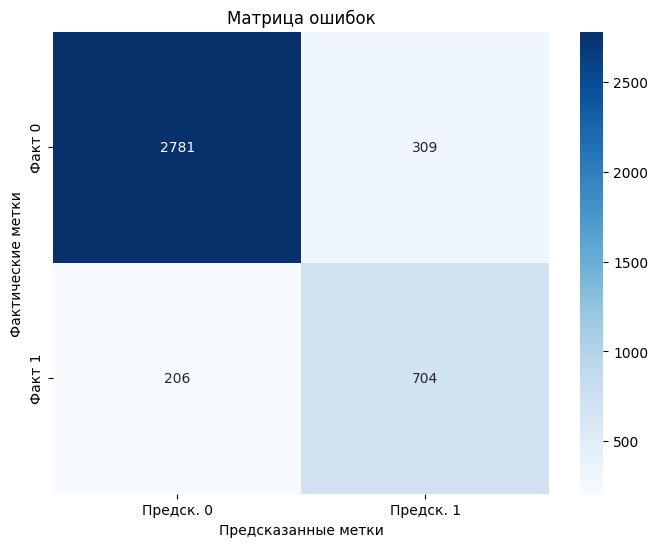

In [16]:
# Сравниваем модели на валидационной выборке
print("\nСравнение моделей на валидационной выборке:")
best_val_score = 0
best_model = None
best_model_name = ""

val_results = {}

for name, model in trained_models.items():
    y_val_pred = model.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    
    val_results[name] = {
        'accuracy': val_accuracy,
        'f1': val_f1
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {val_accuracy:.4f}")
    print(f"  F1-score: {val_f1:.4f}")
    
    # Выбираем лучшую модель по F1-score 
    if val_f1 > best_val_score:
        best_val_score = val_f1
        best_model = model
        best_model_name = name

print(f"\nФинальная лучшая модель: {best_model_name}")
print(f"F1-score на валидации: {best_val_score:.4f}")


print(f"\nЛучшая модель: ({best_model_name}):")
y_val_pred_best = best_model.predict(X_val_scaled)

print(f"Accuracy: {accuracy_score(y_val, y_val_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Предск. 0', 'Предск. 1'],
            yticklabels=['Факт 0', 'Факт 1'])
plt.title('Матрица ошибок')
plt.ylabel('Фактические метки')
plt.xlabel('Предсказанные метки')
plt.show()
#для вывода
#accuracy - точность (общая доля)

#классификация
#precision - точность  
#recall - полнота 
#f1 score - баланс точности и полноты
#support - количество сэмплов каждого класса

#macro avg - Среднее арифметическое по всем классам, где каждый класс имеет одинаковый вес, независимо от его размера.
#weighted avg - Среднее значение, где каждый класс имеет вес, пропорциональный его размеру в датасете.

#матрица ошибок
# TN FP
# FN TP

In [17]:
# Важность признаков для деревьев
if best_model_name in ['Random Forest', 'XGBoost']:
    print(f"\nАнализ важности признаков для {best_model_name}:")
    
    if best_model_name == 'Random Forest':
        feature_importance = best_model.feature_importances_
    else:  # XGBoost
        feature_importance = best_model.feature_importances_
    
    feature_names = (
        [f'mfcc_mean_{i}' for i in range(13)] +
        [f'mfcc_std_{i}' for i in range(13)] +
        [f'chroma_{i}' for i in range(12)] +
        [f'spectral_contrast_{i}' for i in range(7)] +
        ['zcr_mean']
    )
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print("\n15 важных признаков:")
    print(importance_df.head(15))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'].head(15)[::-1], importance_df['importance'].head(15)[::-1])
    plt.xlabel('Важность признака')
    plt.title(f'15 важных признаков ({best_model_name})')
    plt.tight_layout()
    plt.show()


Анализ важности признаков для XGBoost:


ValueError: All arrays must be of the same length

In [18]:
# Предсказания на тестовых данных (лучшая модель)
if len(test_features_df) > 0:
    X_test = prepare_features_for_training(test_features_df)
    X_test_scaled = scaler.transform(X_test) 
    

    test_predictions = best_model.predict(X_test_scaled)
    
    test_features_df['predicted_label'] = test_predictions
    
    print(f"\nПредсказания для тестовых данных ({len(test_features_df)} файлов) ({best_model_name}):")
    print(test_features_df[['filename', 'predicted_label']].head(10))

    test_features_df[['filename', 'predicted_label']].to_csv('test_predictions.csv', index=False)
    print("Предсказания сохранены в test_predictions.csv")


Предсказания для тестовых данных (54503 файлов) (XGBoost):
         filename  predicted_label
0      test1.aiff                0
1     test10.aiff                0
2    test100.aiff                0
3   test1000.aiff                0
4  test10000.aiff                0
5  test10001.aiff                0
6  test10002.aiff                0
7  test10003.aiff                0
8  test10004.aiff                0
9  test10005.aiff                0
Предсказания сохранены в test_predictions.csv


In [19]:
# Сохранение лучшей модели и scaler
model_filename = f'whale_detection_model_{best_model_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_model, model_filename)
joblib.dump(scaler, 'feature_scaler.pkl')

print(f"\nМодель и scaler сохранены:")
print(f"- {model_filename} ({best_model_name})")
print("- feature_scaler.pkl")


Модель и scaler сохранены:
- whale_detection_model_xgboost.pkl (XGBoost)
- feature_scaler.pkl


In [20]:
# информация о сравнении моделей
comparison_df = pd.DataFrame({
    'Model': list(val_results.keys()),
    'CV_Accuracy': [cv_scores_dict[name].mean() for name in val_results.keys()],
    'CV_Std': [cv_scores_dict[name].std() for name in val_results.keys()],
    'Val_Accuracy': [val_results[name]['accuracy'] for name in val_results.keys()],
    'Val_F1': [val_results[name]['f1'] for name in val_results.keys()]
})

print("\nСводная таблица сравнения моделей:")
print(comparison_df.sort_values('Val_F1', ascending=False))

comparison_df.to_csv('model_comparison_results.csv', index=False)
print("Результаты сравнения моделей сохранены в model_comparison_results.csv")


Сводная таблица сравнения моделей:
                 Model  CV_Accuracy    CV_Std  Val_Accuracy    Val_F1
3              XGBoost     0.870375  0.002947       0.87125  0.873607
0        Random Forest     0.842250  0.008224       0.84375  0.851115
1  Logistic Regression     0.764500  0.009486       0.77250  0.789549
2                  SVM     0.506938  0.020480       0.51275  0.551374
Результаты сравнения моделей сохранены в model_comparison_results.csv
